## Wrapper Methods for Feature Selection: RFE and SFS

### 1. Feature Selection / Engineering:
Feature selection is the process of reducing the number of input variables when developing a predictive model. It helps in:
* **Reducing Overfitting:** Less redundant data means less opportunity to make decisions based on noise.
* **Improving Accuracy:** Removing misleading data.
* **Reducing Training Time:** Fewer data points speed up algorithms.

### 2. Recursive Feature Elimination (RFE)
RFE is a backward selection method.
1.  Train the model on all features.
2.  Calculate feature importance (or coefficients).
3.  Remove the least important feature.
4.  Repeat until the desired number of features remains.

### 3. Sequential Feature Selection (SFS)
SFS is a greedy search algorithm. It can be:
* **Forward:** Start with 0 features, add the one that maximizes performance, repeat.
* **Backward:** Start with all features, remove the one that impacts performance the least.

#### 1) Importing Necessary Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.metrics import accuracy_score

#### 2) Generating Synthetic Data:

In [2]:
X, y = make_classification(n_samples=1000,
                           n_features=20, 
                           n_informative=5, 
                           n_redundant=10, 
                           random_state=42)

In [3]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### 3) Baseline Model (No Selection):

In [4]:
base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)
acc_base = accuracy_score(y_test, base_model.predict(X_test))
print(f"Baseline Accuracy (All 20 features): {acc_base:.4f}")

Baseline Accuracy (All 20 features): 0.9467


#### 4) RFE Implementation:

In [5]:
rfe = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=5)
rfe.fit(X_train, y_train)
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

In [6]:
model_rfe = RandomForestClassifier(random_state=42)
model_rfe.fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, model_rfe.predict(X_test_rfe))
print(f"RFE Accuracy (Top 5 features): {acc_rfe:.4f}")

RFE Accuracy (Top 5 features): 0.9167


#### 5) SFS Implementation (Forward):

In [7]:
sfs = SequentialFeatureSelector(RandomForestClassifier(random_state=42, n_jobs=-1), 
                                n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
X_train_sfs = sfs.transform(X_train)
X_test_sfs = sfs.transform(X_test)

In [8]:
model_sfs = RandomForestClassifier(random_state=42)
model_sfs.fit(X_train_sfs, y_train)
acc_sfs = accuracy_score(y_test, model_sfs.predict(X_test_sfs))
print(f"SFS Accuracy (Top 5 features): {acc_sfs:.4f}")

SFS Accuracy (Top 5 features): 0.9367


#### 6) Visualizing Wrapper Methods Performance:

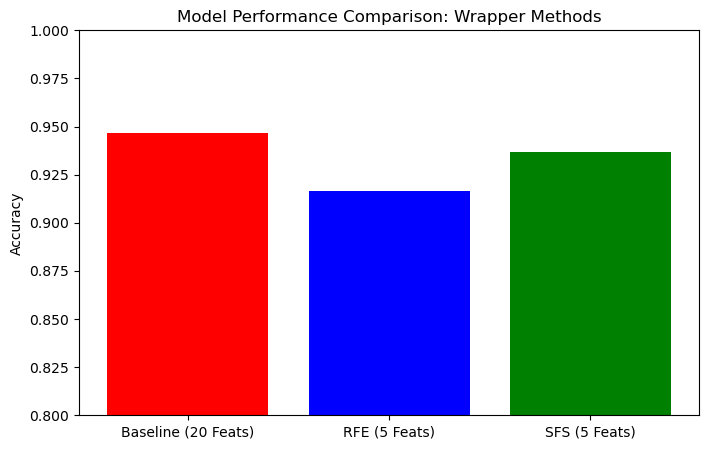

In [11]:
methods = ['Baseline (20 Feats)', 'RFE (5 Feats)', 'SFS (5 Feats)']
scores = [acc_base, acc_rfe, acc_sfs]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores, color=['red', 'blue', 'green'])
plt.ylim(0.8, 1.0)
plt.title("Model Performance Comparison: Wrapper Methods")
plt.ylabel("Accuracy")
plt.show()